# Required Assignment 5.1: Will the Customer Accept the Coupon?

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those who did not

### Data

This data is from the UCI Machine Learning Repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios, including the destination, current time, weather, and passenger, and then asks people whether they will accept the coupon if they are the driver.

#### Importing Libraries

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [34]:
#read in the data
coupons = pd.read_csv('coupons.csv')

### Describing the data

Summary of the numeric variables using the `.describe` method.

In [35]:
coupons_summary = coupons.describe(include='all')
coupons_summary

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684,12684,12684,12684.000000,12684,12684,12684,12684,12684,12684,...,12467,12533,12554,12495,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
unique,3,4,3,NaN,5,5,2,2,8,5,...,5,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN
top,No Urgent Place,Alone,Sunny,NaN,6PM,Coffee House,1d,Female,21,Married partner,...,less1,1~3,1~3,less1,NaN,NaN,NaN,NaN,NaN,NaN
freq,6283,7305,10069,NaN,3230,3996,7091,6511,2653,5100,...,3385,4672,5376,6077,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,63.301798,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,NaN,NaN,NaN,19.154486,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,NaN,NaN,NaN,80.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,NaN,NaN,NaN,80.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,1.000000,0.000000,0.000000,1.000000,1.000000


### Let's get the column information

In [36]:
coupons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

### Getting the missing data information
Analyzing the number of missing values that exists per column in our Dataframe **coupons**

In [37]:
coupons_null = coupons.isnull().sum()
coupons_null

,0
destination,0
passanger,0
weather,0
temperature,0
time,0
coupon,0
expiration,0
gender,0
age,0
maritalStatus,0


<Axes: >

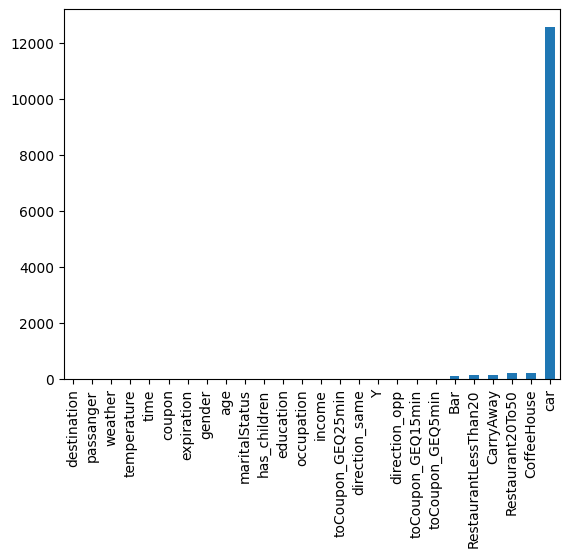

In [38]:
coupons.isnull().sum().sort_values().plot(kind = 'bar')

It is notizable that the column "car" has 12576 null values, which account for more than 90 % of all values.

In [39]:
coupons

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,1
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,0,1,1
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,1,0,1,0


### Distribution Example.
Let's explore the distribution of the Age column.

<Axes: >

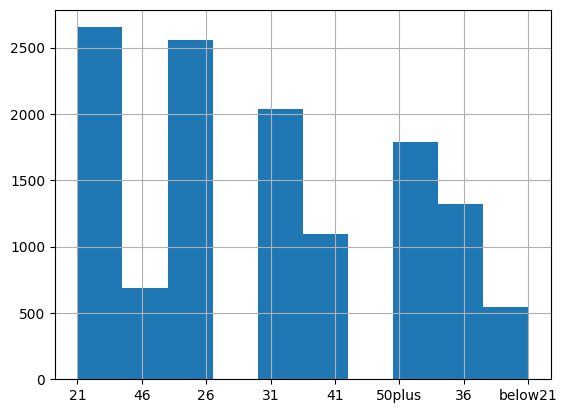

In [40]:
coupons['age'].hist()

There is a data cleanining task here that can be done, by mapping the text values to meaningful numbers and transform the column from text to number.

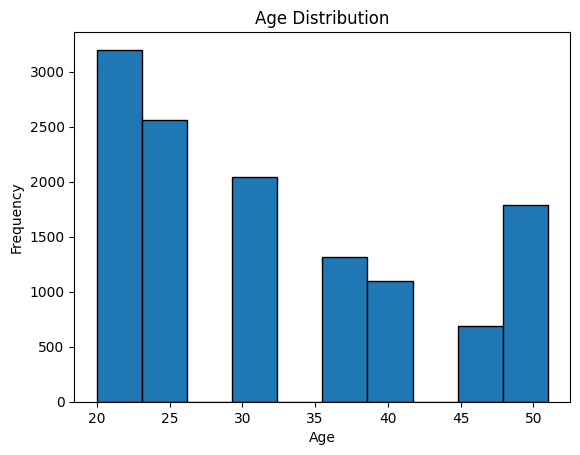

In [41]:
# Mapping dictionary
age_mapping_uncleaned = {'below21': '20', '50plus': '51'}

# Map the text values to the numeric values
coupons_age_uncleaned = coupons['age'].replace(age_mapping_uncleaned)

# Add a new column as numeric
coupons['age_numeric'] = pd.to_numeric(coupons_age_uncleaned)

# Plot the histogram of age_numeric with the title 'Age distribution'

plt.hist(coupons['age_numeric'], bins=10, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()



The customers are distributed in four groups. Less than 26, between 29 and 33, 36 to 43, and 44 to 53.

### Discovering the data
Let's show the distribution of each column of the data to determine some more facts

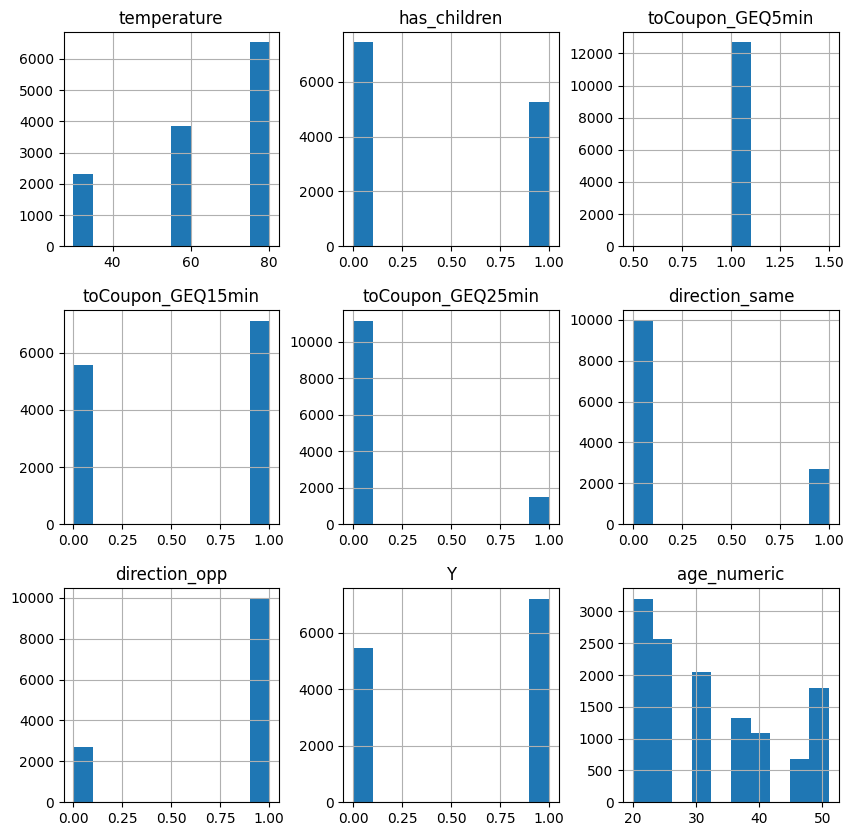

In [42]:
# For each numeric column, show the distribution of the values as subplots
coupons.hist(figsize=(10, 10))
plt.show()

A few takeaways from above histograms are:
- Most passangers are alone.
- The weather category happening more is sunny.
- The work category containing more people is 'Unemployed'.
- The most popular income value is between 25k and 38k.

### Query the data using Pandas


In [43]:
# Get the customers with CoffeeHouse greater than 8 and maritalStatus is single
coupons.query('CoffeeHouse == "gt8" and maritalStatus == "Single"')

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y,age_numeric
154,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,26,Single,...,gt8,gt8,gt8,1,0,0,0,1,1,26
155,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,26,Single,...,gt8,gt8,gt8,1,0,0,0,1,0,26
156,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,26,Single,...,gt8,gt8,gt8,1,0,0,0,1,1,26
157,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,26,Single,...,gt8,gt8,gt8,1,1,0,0,1,0,26
158,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,26,Single,...,gt8,gt8,gt8,1,0,0,0,1,1,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12278,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,4~8,4~8,4~8,1,0,0,0,1,1,26
12279,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,4~8,4~8,4~8,1,0,0,1,0,1,26
12280,Work,Alone,Snowy,30,7AM,Restaurant(<20),1d,Male,26,Single,...,4~8,4~8,4~8,1,1,0,0,1,0,26
12281,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,4~8,4~8,4~8,1,1,1,0,1,1,26


In [44]:
# What is the coupon most popular among them all and how many times appear?
coupons['coupon'].value_counts()

,count
coupon,
Coffee House,3996
Restaurant(<20),2786
Carry out & Take away,2393
Bar,2017
Restaurant(20-50),1492


## Findings
Let's state the problem for each specific coupon group

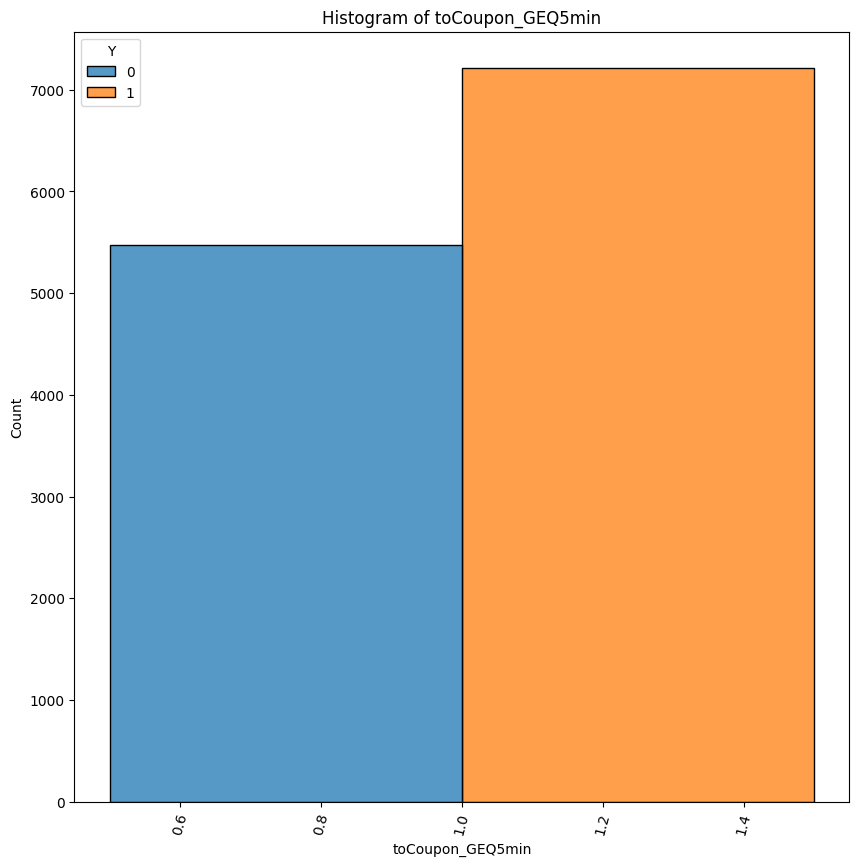

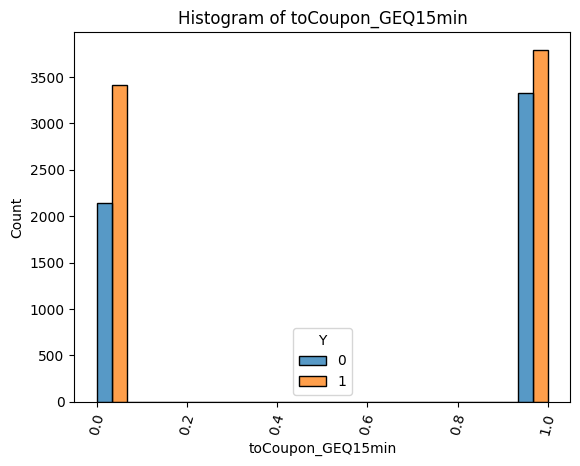

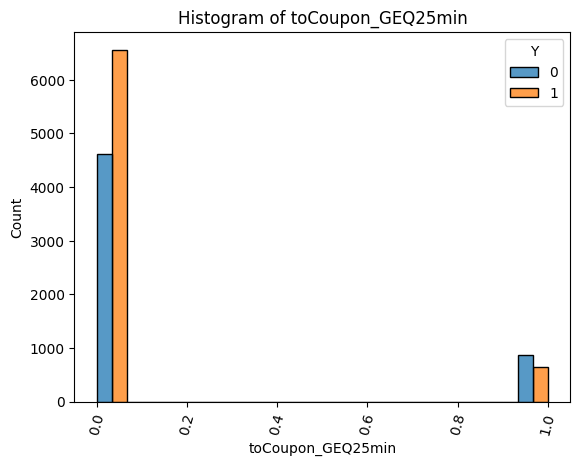

In [45]:
# Get the column names that contain Coupon
coupon_columns = [col for col in coupons.columns if 'Coupon' in col]

# Plot the histogram of each column of coupons group using seaborn
plt.figure(figsize=(10, 10))

for i, col in enumerate(coupon_columns):
    ax = sns.histplot(data=coupons, x=coupons[col], hue='Y',multiple="dodge")
    ax.tick_params(axis='x', rotation=75)
    plt.title(f'Histogram of {col}')
    plt.show()

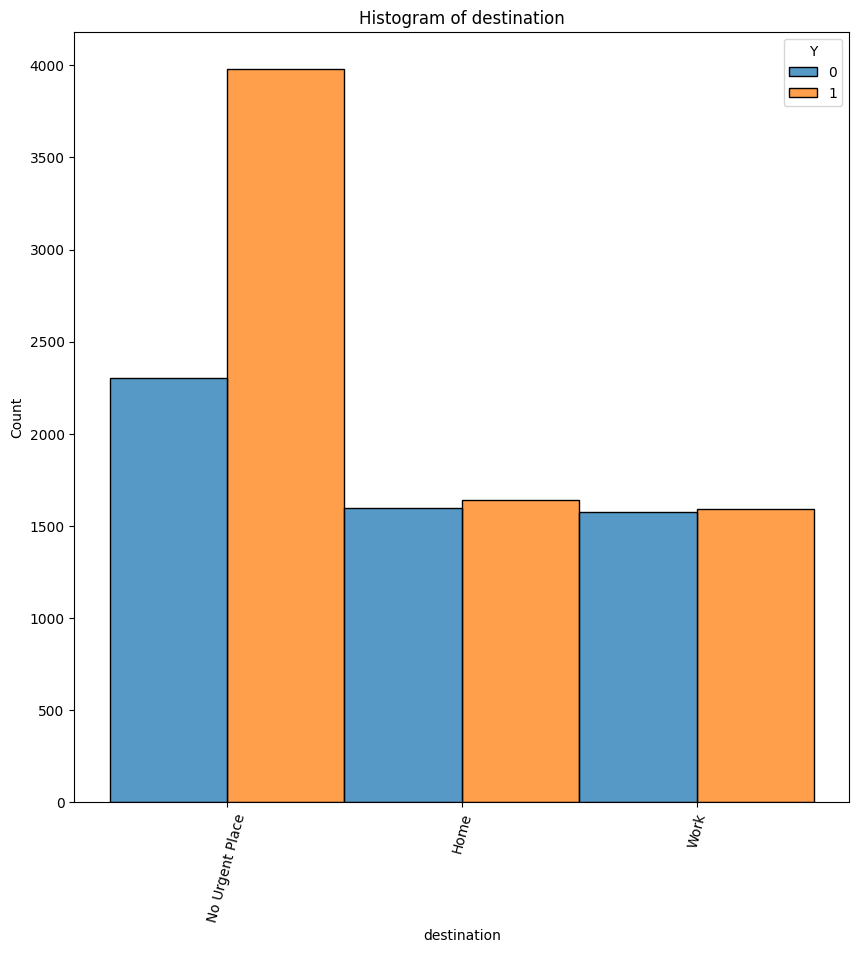

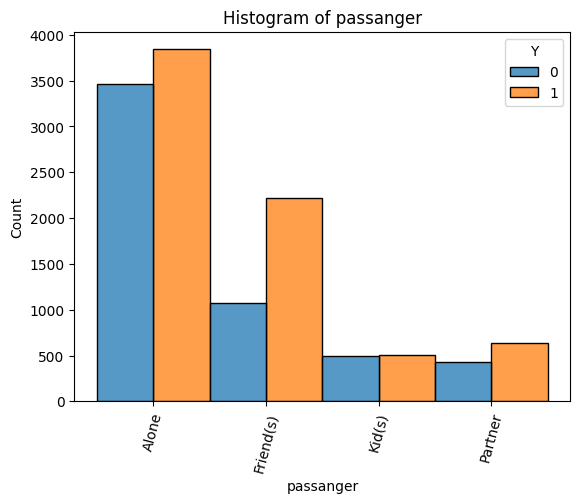

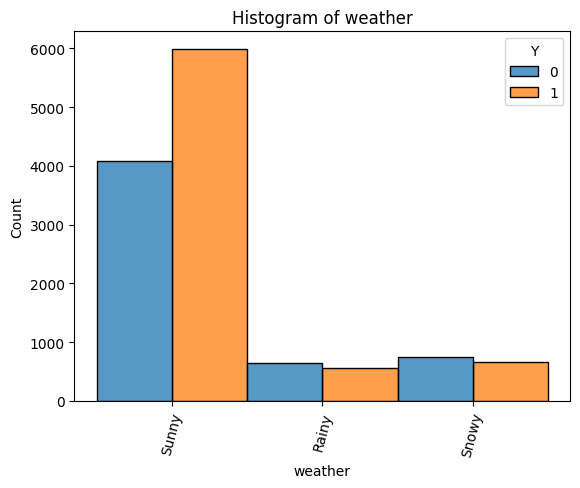

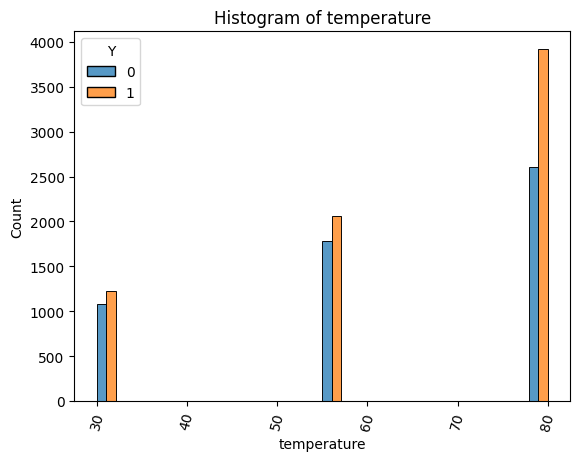

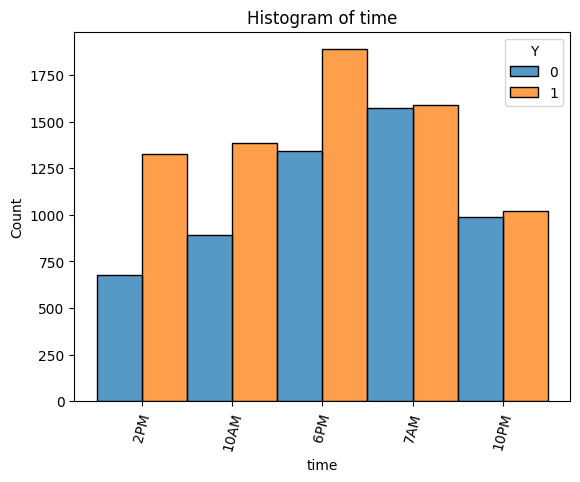

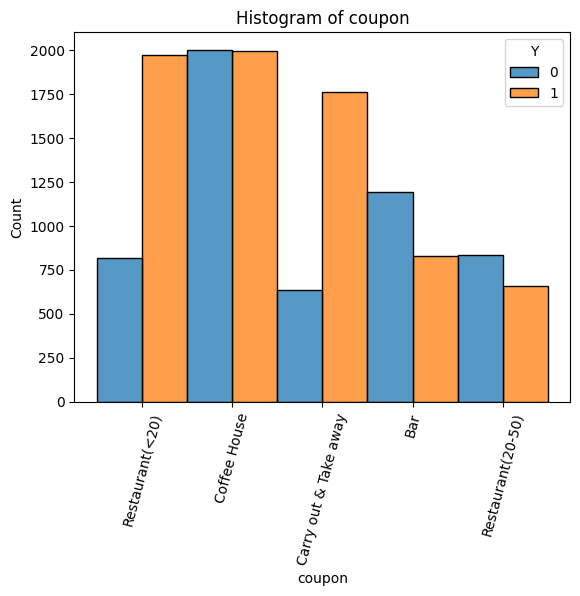

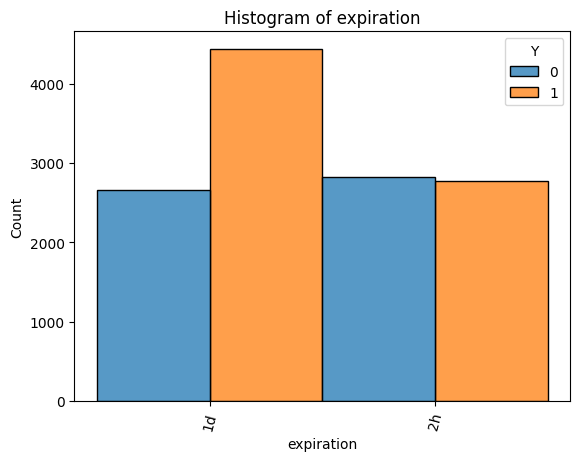

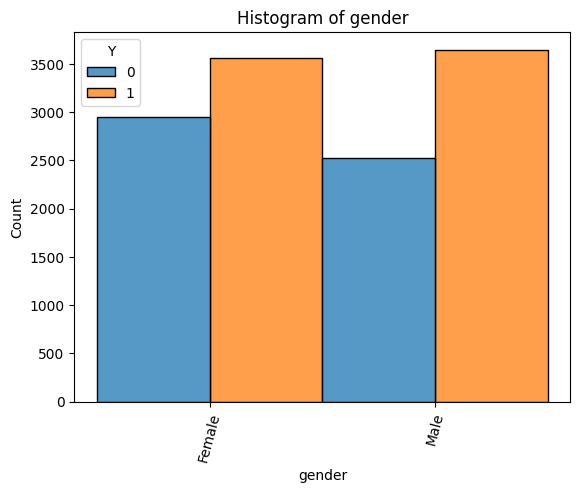

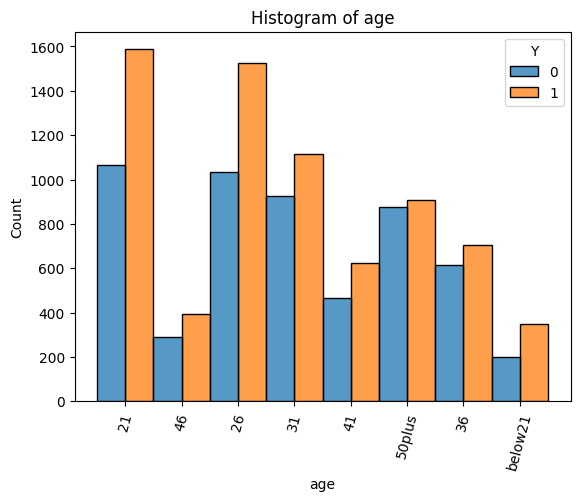

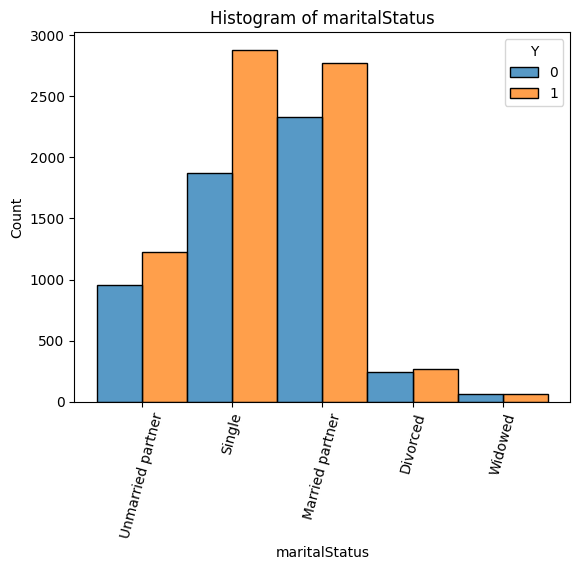

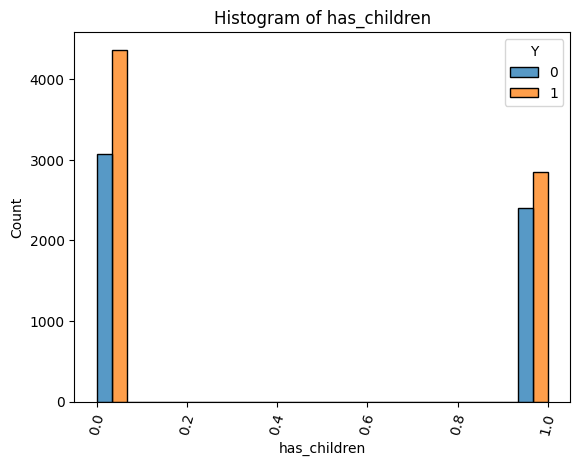

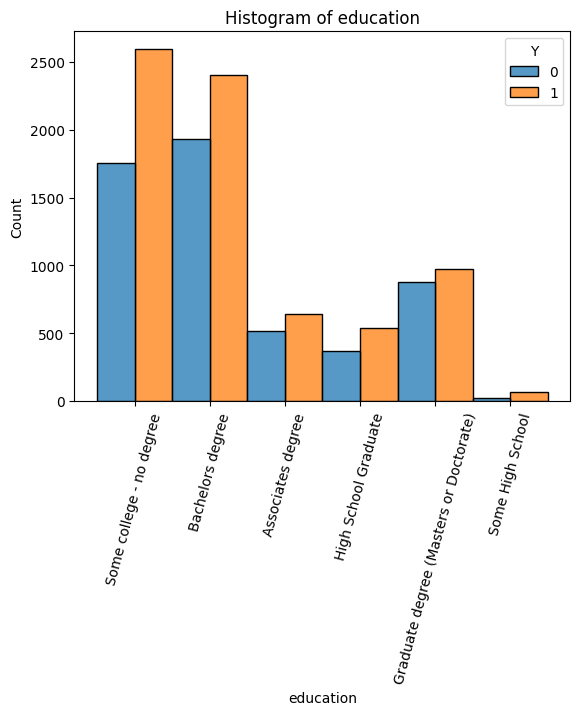

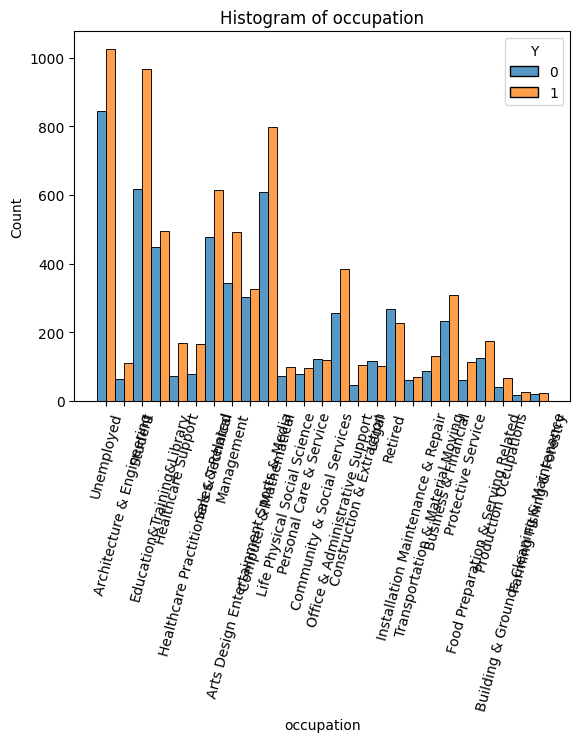

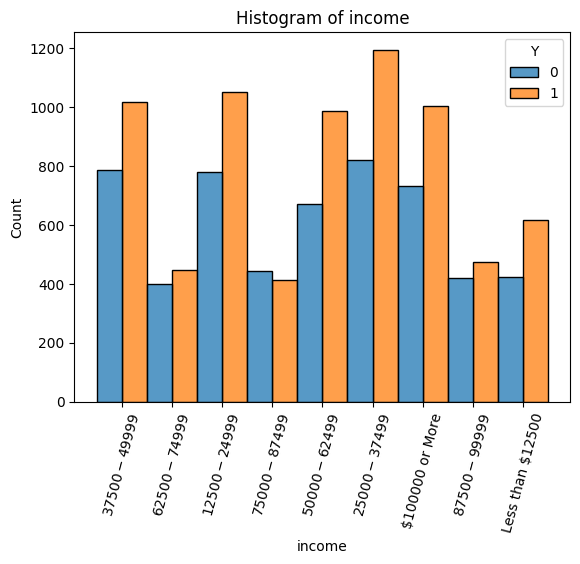

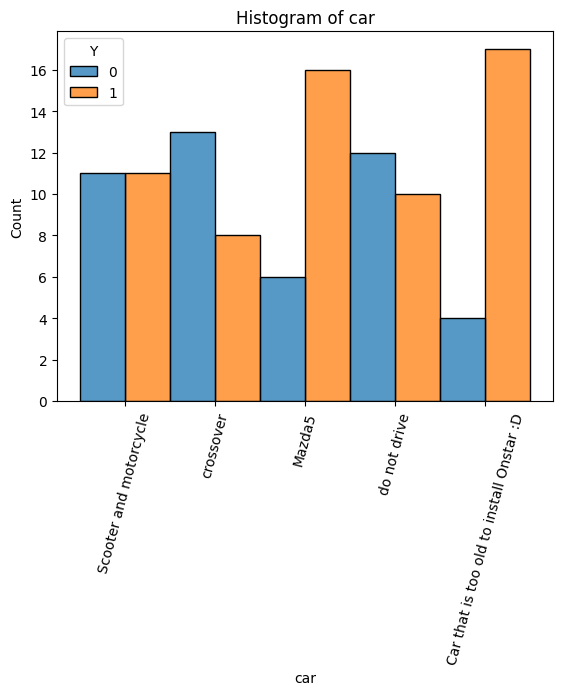

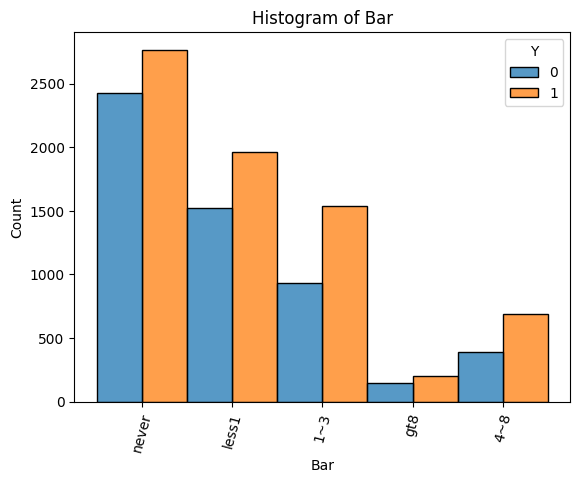

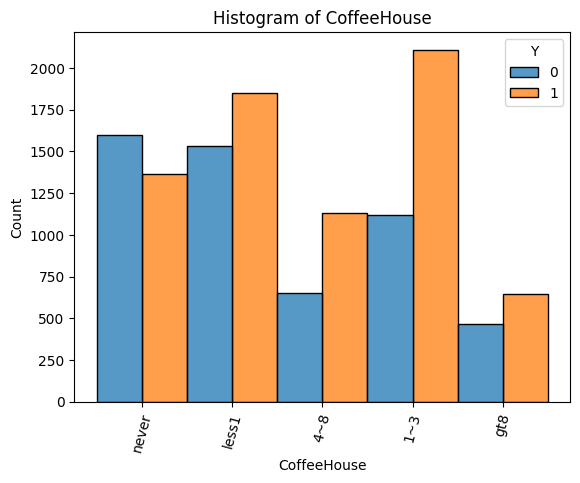

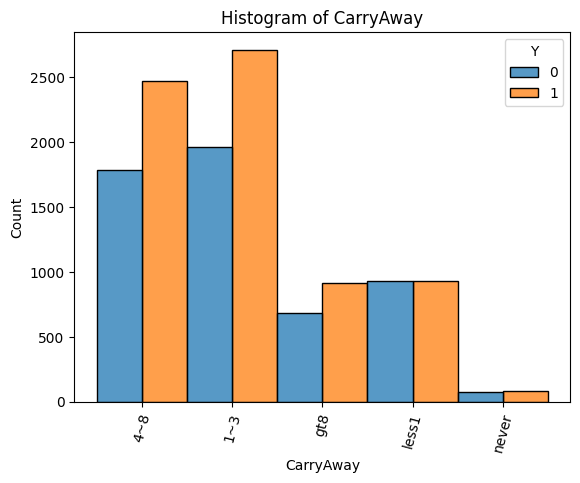

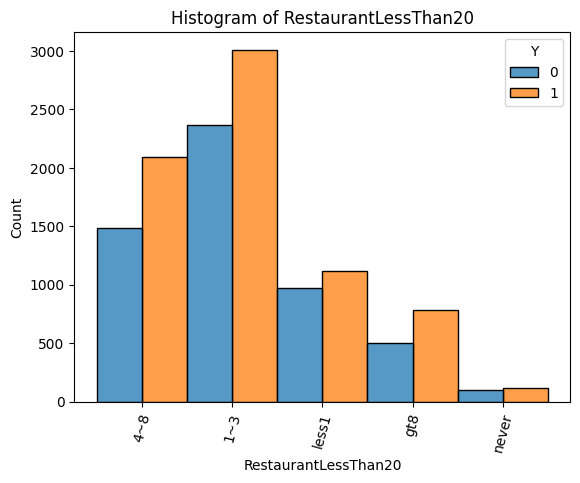

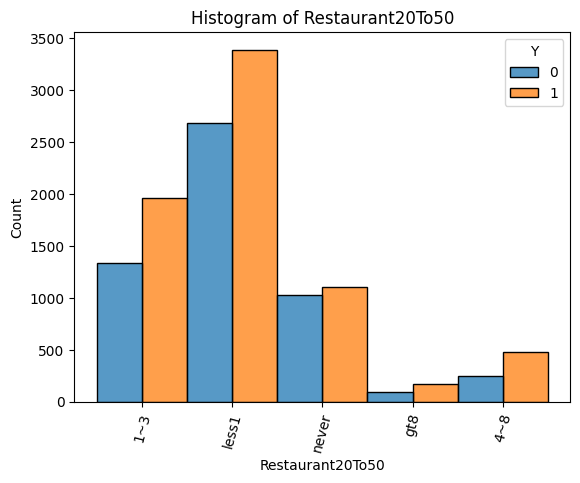

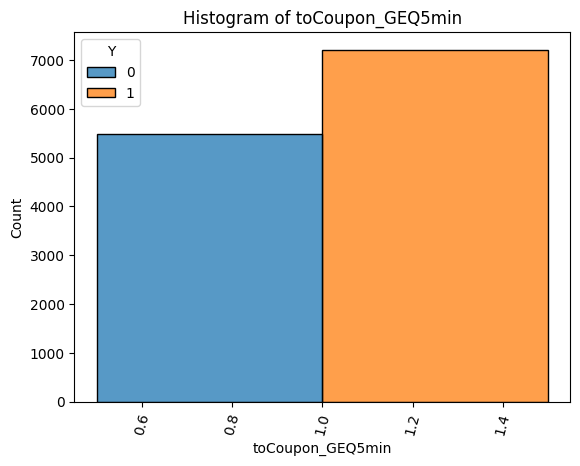

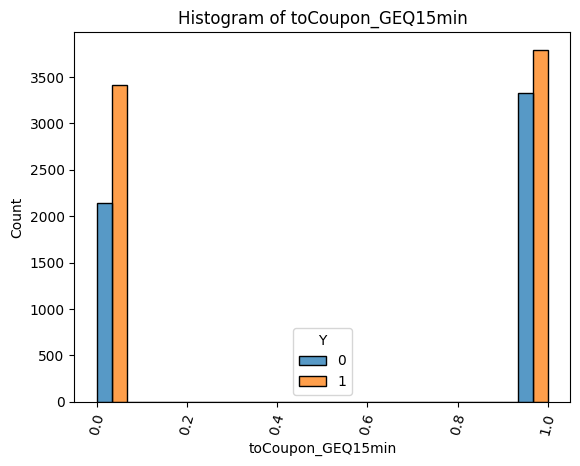

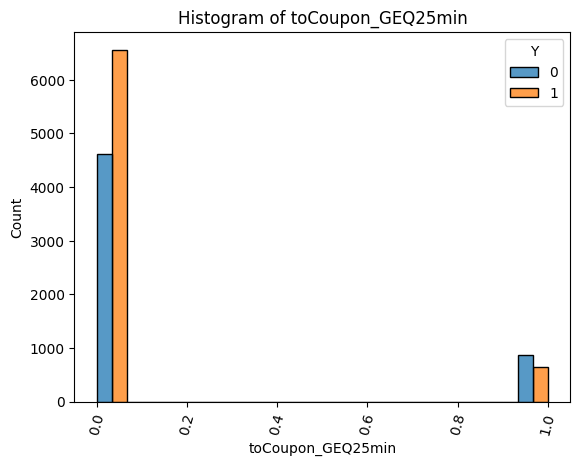

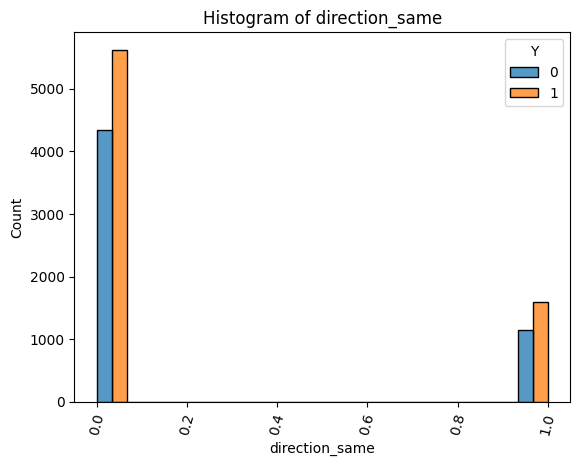

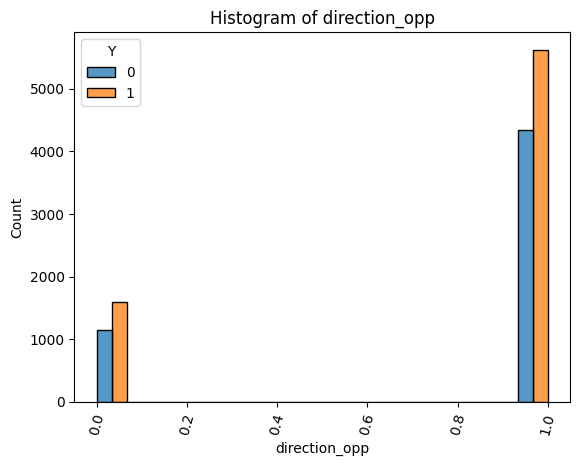

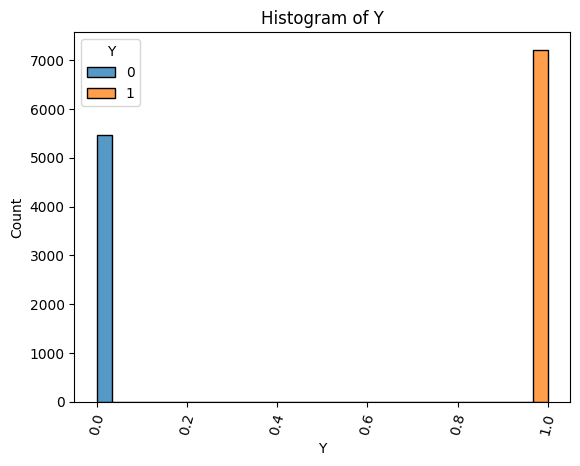

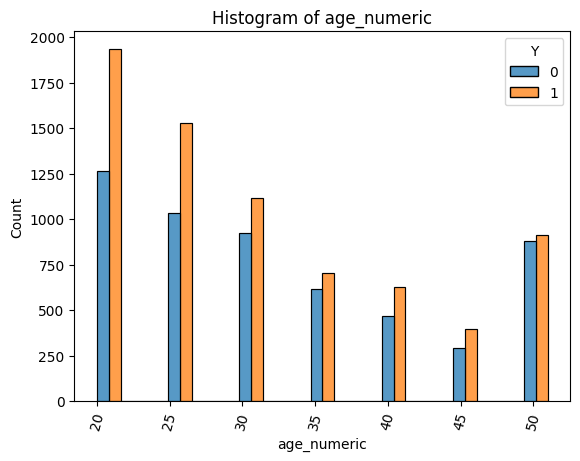

In [46]:
# Plot the histogram of each column of coupons using seaborn
plt.figure(figsize=(10, 10))

for i, col in enumerate(coupons.columns):
    ax = sns.histplot(data=coupons, x=coupons[col], hue='Y',multiple="dodge")
    ax.tick_params(axis='x', rotation=75)
    plt.title(f'Histogram of {col}')
    plt.show()

According to above histograms, we can detect that:
- **Destination**: Big differences in accepted coupons where the category is 'No place urgent' .
- **Passanger**: 'Alone' category shows most occurrences with values up to 3500, with more customers accepting the coupons in this category. The other groups show values of up to 1000 responses and accepted offers are higher than rejected ones.
- **Weather**: 'Sunny' category shows most occurrences with values up to 6000, with more customers accepting the coupons in this category. The other groups show values of up to 1000 responses and rejected offers are higher than accepted ones.
- **Temperature**: '80' degrees category shows most occurrences with values up to 4000, with more customers accepting the coupons in this category. The other groups show values of up to 2000 responses and accepted offers are higher than rejected ones. Indicates that cold temperatures do not help to accept the coupons.
- **Time**: '6PM and 7PM' timings categories show most occurrences with values up to 1750, with more customers accepting the coupons in this category. The other groups show values a bit lower, but the coupons are distributed more evenly .
- **Coupon**: 'Restaurant(20) and Coffee House' degrees categories show most occurrences with values up to 2000, with more customers accepting the coupons in this category. The other groups Bar, Carry Out & take away and restaurant20-50 show accepted offers higher than rejected ones. Indicates that customers prefer cheaper restaurants and coffee to be taken away home.
- **Expiration**: '1d' category shows most occurrences with values up to 4000, with more customers accepting the coupons in this category. The other group show values of up to 3000 responses and accepted offers are lower than rejected ones. Indicates that customers prefer longer valid coupons.
- **Gender**: Evenly distributed between male and female, with accepted coupons higher than rejected ones.
- **marital Status**: 'Single and Married partner' categories shows most occurrences with values up to 3000, with more customers accepting the coupons in this category. The other groups Unmarried partner, divorced and widowed show values of up to 1500 responses and accepted offers are higher than rejected ones. Indicates that cold temperatures do not help to accept the coupons.
- Has_children: '0' as no children category shows most occurrences with values up to 4000, with more customers accepting the coupons in this category. The other group with children show values of up to 3000 responses and accepted offers are higher than rejected ones. Indicates that having no children impacts accepting more coupons.
- **Education**: 'No degree or bachelors' degrees categories show most occurrences with values up to 2500, with more customers accepting the coupons in this category. The other groups show values of up to 1000 responses and accepted offers are higher than rejected ones. Indicates that people with less studies tend to accept more coupons than well educated people.
- **Occupation**: Highlights among all categories that Unemployed customers are the ones more prominent to accept coupons.
- Income: This case, in contrary, shows that medium-high income individuals ask for accepted coupons, which is a bit contraditory.
- **car**: Evenly distributed.
- **Bar**: 'Never' category shows most occurrences with values up to 2500, with more customers accepting the coupons in this category. The other groups show values of up to 2000 responses and accepted offers are higher than rejected ones. Indicates that customers tend to not take coupons for bar offers.
- **CoffeeHouse**: 'less1 and 1~3' categories show most occurrences with values more than 2000, with more customers accepting the coupons in this category. The other groups show values of up to 2000 responses and accepted offers are higher than rejected ones. Indicates that customers tend to take coupons for coffee at the house between 1 to 3 times mostly.
- **CarryAway**: '1~3 and 4~8' categories show most occurrences with values more than 2000, with more customers accepting the coupons in this category. The other groups show values of up to 1000 responses and accepted offers are higher than rejected ones. Indicates that customers tend to take coupons to eat away between 1 to 8 times mostly.
- **RestaurantLessthan20**: '1~3 and 4~8' categories show most occurrences with values more than 2000, with more customers accepting the coupons in this category. The other groups show values of up to 1000 responses and accepted offers are higher than rejected ones. Indicates that customers tend to take coupons to eat away between 1 to 8 times mostly.
- **Restaurant20to50**: 'less1 and 1~3' categories show most occurrences with values more than 3500, with more customers accepting the coupons in this category. The other groups show values of up to 1000 responses and accepted offers are higher than rejected ones. Indicates that customers tend to take coupons to eat away between 1 to 3 times mostly.
- **ToCoupon-GEQ5min**: coupons of up to 5 min have more customers accepting the coupons in this category.
- ToCoupon-GEQ15min: coupons of up to 15 min have more customers accepting the coupons in this category.
- **ToCoupon-GEQ25min**: coupons of up to 25 min have more customers rejecting the coupons in this category by a big difference, so there is an issue with these offers.
- **direction_same**: coupons in the same direction have more customers rejecting the coupons in this category.
- **direction_opp**: coupons in the same direction have more customers accepting the coupons in this category.
Overall, more customers accept the coupons with values of around 7000 answers and 5500 rejections.

## Next steps and recommendations
As future tasks, we could forecast using ML or AI algorithms, the behaviour of customers based on this data to predict wether customers with similar charateristic could potentially accepted specific coupons, and therefore target more precisely the audience to save on marketing and operational costs.


In [47]:
# From previous histograms created, please expose the main insights that you find where Y=1 means is accepted
